# 📊 Exploratory Data Analysis — engineered_features_raw.csv

**Dataset:** 32,593 sinh viên × 51 features — OULAD

| Phần | Nội dung |
|------|----------|
| 1 | Phân phối target & tổng quan |
| 2 | Phân phối theo Course Type (code_module) |
| 3 | Phân phối theo Cohort (code_presentation) |
| 4 | Phân phối theo Enrollment Period |
| 5 | Engagement features — distributions |
| 6 | Login frequency vs Final Score |
| 7 | Video Completion vs Submission Timeliness |
| 8 | Binary flags & behavior patterns |
| 9 | Correlation analysis |
| 10 | Tổng kết insights |

In [1]:
import micropip
await micropip.install(['pandas', 'seaborn'])

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PALETTE = {'Distinction': '#2ecc71', 'Pass': '#3498db', 'Fail': '#e67e22', 'Withdrawn': '#e74c3c'}
ORDER   = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
LEGEND  = [mpatches.Patch(color=PALETTE[r], label=r) for r in ORDER]

df = pd.read_csv('engineered_features_clean.csv')
label_map = {'Distinction': 3, 'Pass': 2, 'Fail': 1, 'Withdrawn': 0}
df['result_num'] = df['final_result'].map(label_map)

# Enrollment period group
df['enroll_group'] = pd.cut(
    df['registration_delay_days'],
    bins=[-400, -100, -30, 0, 200],
    labels=['Very Early\n(>100d before)', 'Early\n(30–100d)', 'Near Start\n(0–30d)', 'Late\n(after start)']
)

print(f'Shape: {df.shape}')
df.head(3)

Shape: (32593, 55)


,id_student,code_module,code_presentation,login_weekly,video_completion_rate,forum_posts_count,days_to_first_filled,submission_timeliness_days,never_started,missed_submission,...,assignment_timeliness_score,login_time_Afternoon,login_time_Evening,login_time_Morning,login_time_Night,final_result,final_result_encoded,passed,result_num,enroll_group
0,11391,AAA,2013J,2,0.934,5,9.0,-0.2,0,0,...,-0.319689,1,0,0,0,Pass,2,1,2,Very Early\n(>100d before)
1,28400,AAA,2013J,6,0.879,0,2.0,-1.5,0,0,...,-0.394787,0,1,0,0,Pass,2,1,2,Early\n(30–100d)
2,30268,AAA,2013J,0,0.522,0,90.0,3.4,1,1,...,-0.394787,0,1,0,0,Withdrawn,0,0,0,Early\n(30–100d)


## 1. Phân Phối Target Label

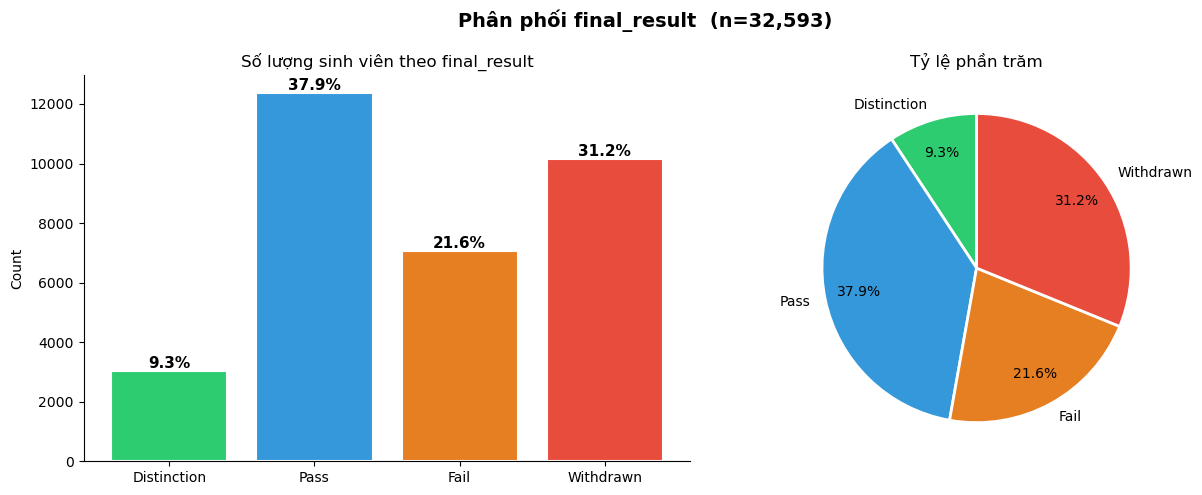

              count  percent
final_result                
Distinction    3024      9.3
Pass          12361     37.9
Fail           7052     21.6
Withdrawn     10156     31.2


In [3]:
counts = df['final_result'].value_counts().reindex(ORDER)
pcts   = counts / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(ORDER, counts, color=[PALETTE[k] for k in ORDER], edgecolor='white', linewidth=1.5)
for bar, pct in zip(bars, pcts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{pct:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Số lượng sinh viên theo final_result', fontsize=12)
axes[0].set_ylabel('Count')
axes[0].spines[['top','right']].set_visible(False)

axes[1].pie(counts, labels=ORDER, colors=[PALETTE[k] for k in ORDER],
            autopct='%1.1f%%', startangle=90, pctdistance=0.78,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Tỷ lệ phần trăm', fontsize=12)

plt.suptitle(f'Phân phối final_result  (n={len(df):,})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(pd.DataFrame({'count': counts, 'percent': pcts.round(1)}))

## 2. So Sánh Theo Course Type (code_module)

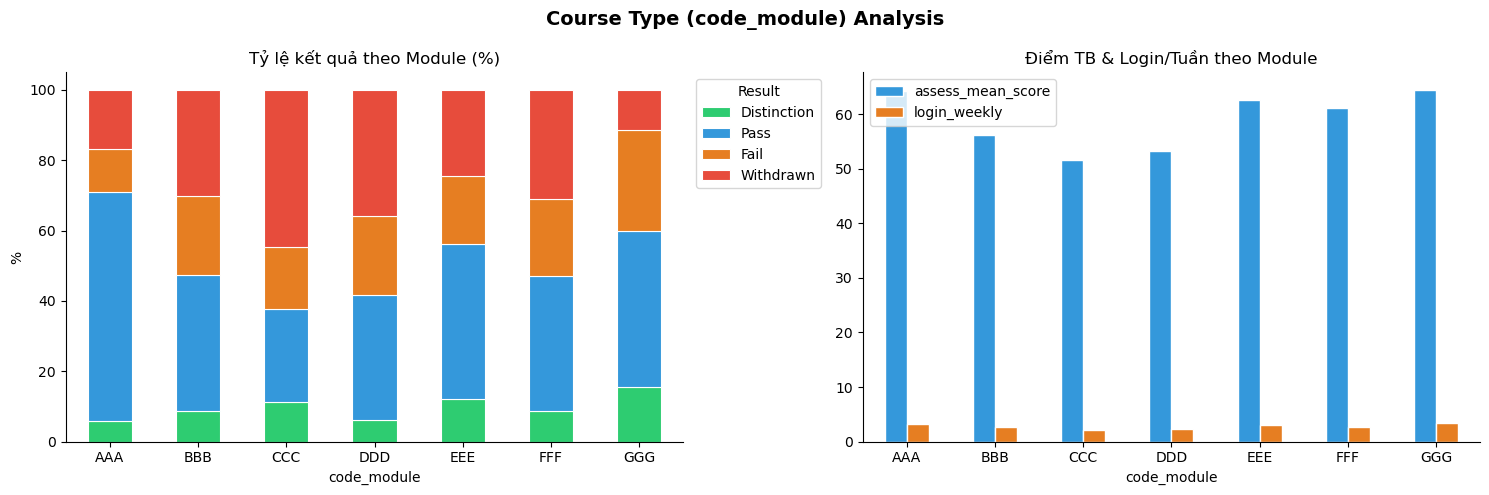


Key metrics by module:
             assess_mean_score  assessment_completion_rate  login_weekly  \
code_module                                                                
AAA                     64.269                       0.842         3.214   
BBB                     56.282                       0.597         2.599   
CCC                     51.610                       0.475         2.191   
DDD                     53.222                       0.585         2.248   
EEE                     62.703                       0.673         3.047   
FFF                     61.206                       0.588         2.641   
GGG                     64.465                       0.667         3.365   

             video_completion_rate  
code_module                         
AAA                          0.540  
BBB                          0.447  
CCC                          0.386  
DDD                          0.406  
EEE                          0.495  
FFF                          0.4

In [4]:
modules = sorted(df['code_module'].unique())
mod_result = df.groupby(['code_module','final_result']).size().unstack(fill_value=0).reindex(columns=ORDER)
mod_pct    = mod_result.div(mod_result.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

mod_pct.plot(kind='bar', stacked=True, ax=axes[0], color=[PALETTE[k] for k in ORDER],
             edgecolor='white', linewidth=0.8)
axes[0].set_title('Tỷ lệ kết quả theo Module (%)', fontsize=12)
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=0)
axes[0].spines[['top','right']].set_visible(False)
axes[0].legend(title='Result', bbox_to_anchor=(1.01, 1))

# Key performance metrics by module
mod_metrics = df.groupby('code_module')[['assess_mean_score','assessment_completion_rate',
                                          'login_weekly','video_completion_rate']].mean()
mod_metrics[['assess_mean_score','login_weekly']].plot(kind='bar', ax=axes[1],
    color=['#3498db','#e67e22'], edgecolor='white')
axes[1].set_title('Điểm TB & Login/Tuần theo Module', fontsize=12)
axes[1].tick_params(axis='x', rotation=0)
axes[1].spines[['top','right']].set_visible(False)
axes[1].legend()

plt.suptitle('Course Type (code_module) Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKey metrics by module:')
print(mod_metrics.round(3))

## 3. So Sánh Theo Cohort (code_presentation)

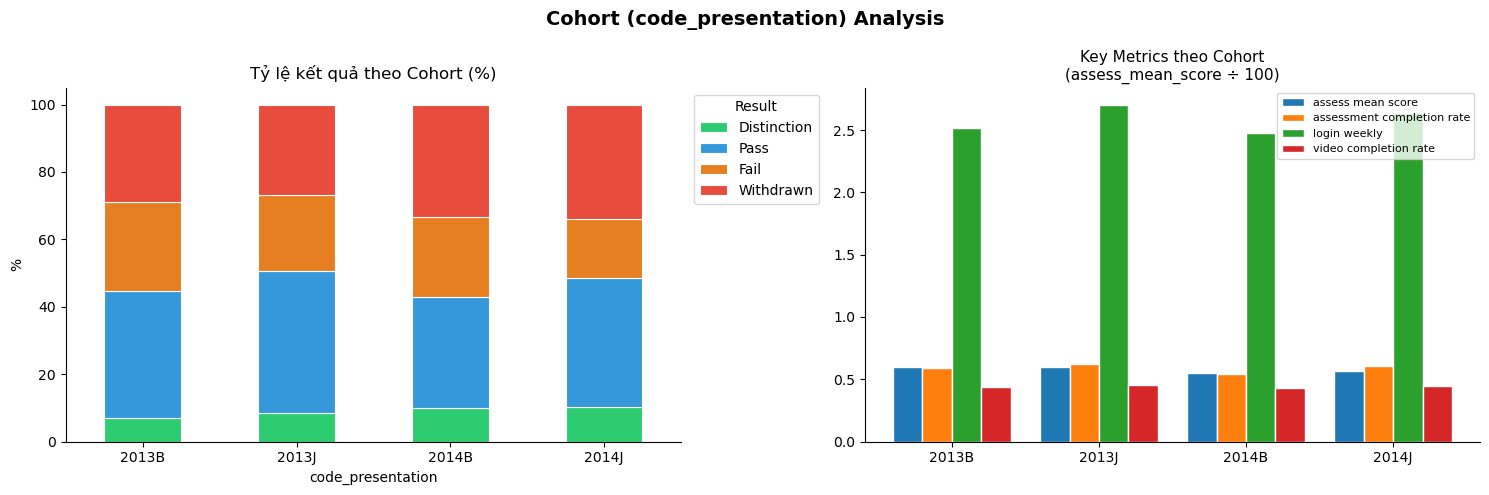


Key metrics by cohort:
                   assess_mean_score  assessment_completion_rate  \
code_presentation                                                  
2013B                         59.633                       0.594   
2013J                         59.683                       0.622   
2014B                         55.112                       0.542   
2014J                         56.922                       0.608   

                   login_weekly  video_completion_rate  
code_presentation                                       
2013B                     2.514                  0.434  
2013J                     2.704                  0.458  
2014B                     2.476                  0.432  
2014J                     2.639                  0.447  


In [5]:
pres_result = df.groupby(['code_presentation','final_result']).size().unstack(fill_value=0).reindex(columns=ORDER)
pres_pct    = pres_result.div(pres_result.sum(axis=1), axis=0) * 100

pres_metrics = df.groupby('code_presentation')[[
    'assess_mean_score','assessment_completion_rate','login_weekly','video_completion_rate'
]].mean().round(3)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pres_pct.plot(kind='bar', stacked=True, ax=axes[0], color=[PALETTE[k] for k in ORDER],
              edgecolor='white', linewidth=0.8)
axes[0].set_title('Tỷ lệ kết quả theo Cohort (%)', fontsize=12)
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=0)
axes[0].spines[['top','right']].set_visible(False)
axes[0].legend(title='Result', bbox_to_anchor=(1.01, 1))

x = np.arange(len(pres_metrics))
w = 0.2
for i, col in enumerate(['assess_mean_score','assessment_completion_rate','login_weekly','video_completion_rate']):
    vals = pres_metrics[col]
    if col == 'assess_mean_score':
        vals = vals / 100  # normalize to same scale
    axes[1].bar(x + i*w, vals, width=w, label=col.replace('_',' '), edgecolor='white')
axes[1].set_xticks(x + w*1.5)
axes[1].set_xticklabels(pres_metrics.index)
axes[1].set_title('Key Metrics theo Cohort\n(assess_mean_score ÷ 100)', fontsize=11)
axes[1].spines[['top','right']].set_visible(False)
axes[1].legend(fontsize=8)

plt.suptitle('Cohort (code_presentation) Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKey metrics by cohort:')
print(pres_metrics)

## 4. So Sánh Theo Enrollment Period

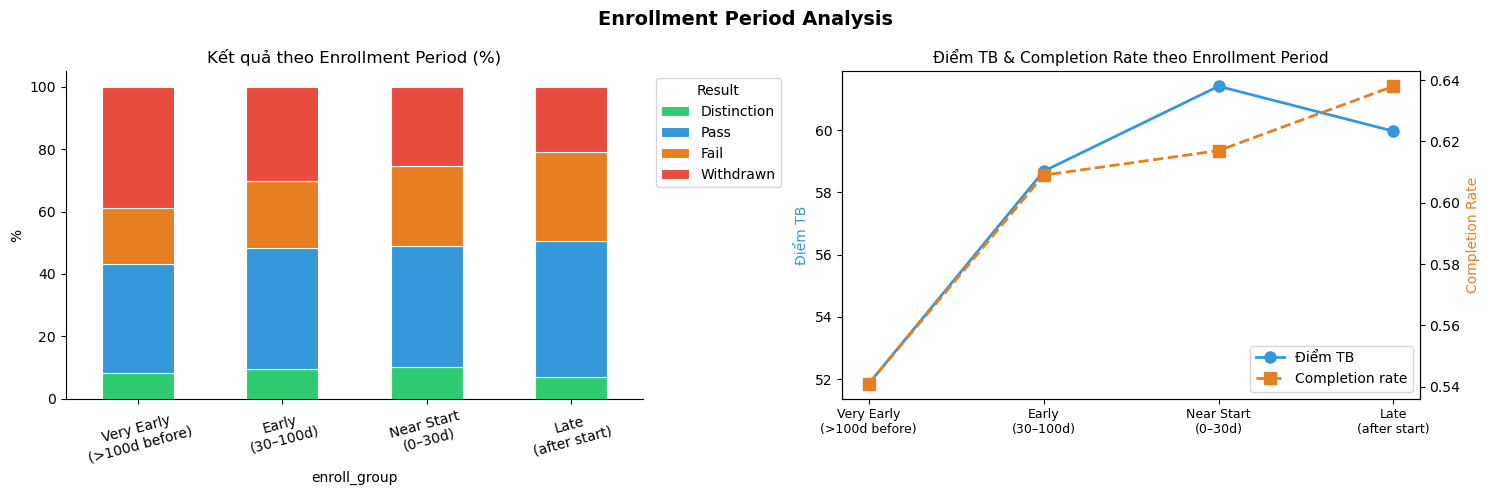


Key metrics by enrollment period:
                            assess_mean_score  assessment_completion_rate  \
enroll_group                                                                
Very Early\n(>100d before)             51.856                       0.541   
Early\n(30–100d)                       58.678                       0.609   
Near Start\n(0–30d)                    61.407                       0.617   
Late\n(after start)                    59.964                       0.638   

                            login_weekly  
enroll_group                              
Very Early\n(>100d before)         2.394  
Early\n(30–100d)                   2.624  
Near Start\n(0–30d)                2.746  
Late\n(after start)                3.188  


In [6]:
enroll_result = df.groupby(['enroll_group','final_result']).size().unstack(fill_value=0).reindex(columns=ORDER)
enroll_pct    = enroll_result.div(enroll_result.sum(axis=1), axis=0) * 100

enroll_metrics = df.groupby('enroll_group')[[
    'assess_mean_score','assessment_completion_rate','login_weekly'
]].mean().round(3)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

enroll_pct.plot(kind='bar', stacked=True, ax=axes[0], color=[PALETTE[k] for k in ORDER],
                edgecolor='white', linewidth=0.8)
axes[0].set_title('Kết quả theo Enrollment Period (%)', fontsize=12)
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=15)
axes[0].spines[['top','right']].set_visible(False)
axes[0].legend(title='Result', bbox_to_anchor=(1.01, 1))

x = np.arange(len(enroll_metrics))
axes[1].plot(x, enroll_metrics['assess_mean_score'], 'o-', color='#3498db', linewidth=2, markersize=8, label='Điểm TB')
ax2 = axes[1].twinx()
ax2.plot(x, enroll_metrics['assessment_completion_rate'], 's--', color='#e67e22', linewidth=2, markersize=8, label='Completion rate')
axes[1].set_xticks(x)
axes[1].set_xticklabels(enroll_metrics.index, fontsize=9)
axes[1].set_title('Điểm TB & Completion Rate theo Enrollment Period', fontsize=11)
axes[1].set_ylabel('Điểm TB', color='#3498db')
ax2.set_ylabel('Completion Rate', color='#e67e22')
axes[1].spines[['top']].set_visible(False)
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1+lines2, labels1+labels2, loc='lower right')

plt.suptitle('Enrollment Period Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKey metrics by enrollment period:')
print(enroll_metrics)

## 5. Engagement Features — Distributions theo final_result

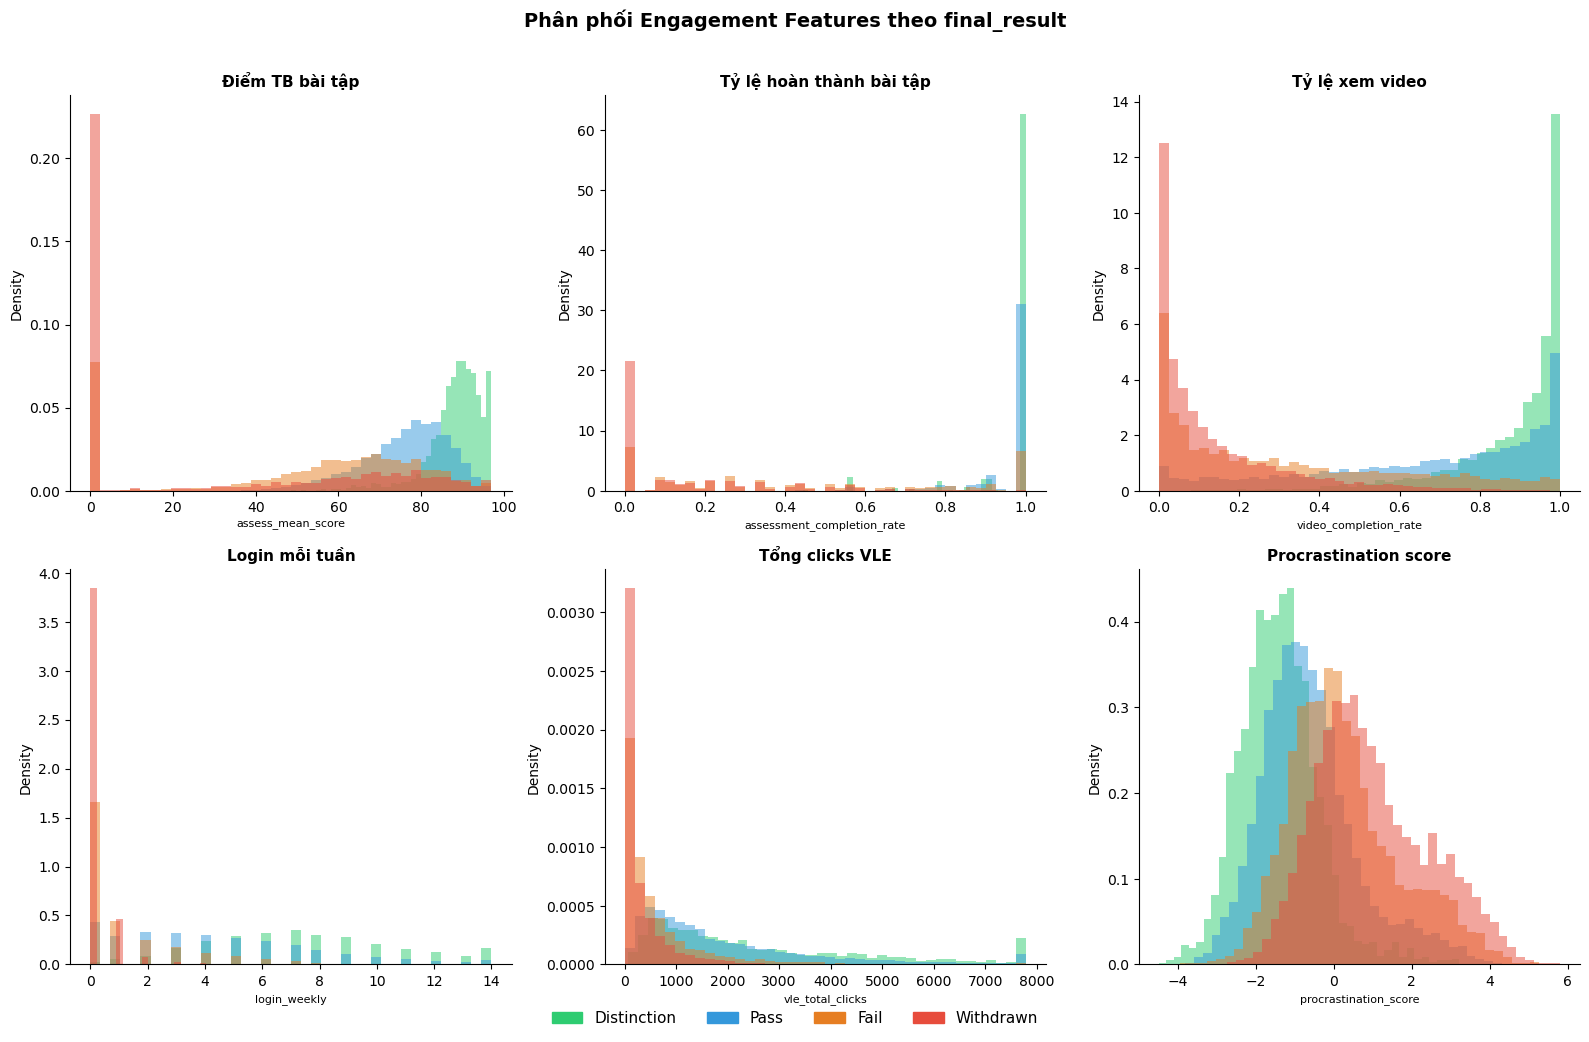

In [7]:
key_features = {
    'assess_mean_score':          'Điểm TB bài tập',
    'assessment_completion_rate': 'Tỷ lệ hoàn thành bài tập',
    'video_completion_rate':      'Tỷ lệ xem video',
    'login_weekly':               'Login mỗi tuần',
    'vle_total_clicks':           'Tổng clicks VLE',
    'procrastination_score':      'Procrastination score',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (col, label) in zip(axes.flatten(), key_features.items()):
    for result in ORDER:
        data = df[df['final_result'] == result][col].dropna()
        ax.hist(data, bins=40, alpha=0.5, color=PALETTE[result], label=result, density=True)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('Density')
    ax.spines[['top','right']].set_visible(False)

fig.legend(handles=LEGEND, loc='lower center', ncol=4, fontsize=11,
           bbox_to_anchor=(0.5, -0.02), frameon=False)
plt.suptitle('Phân phối Engagement Features theo final_result', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

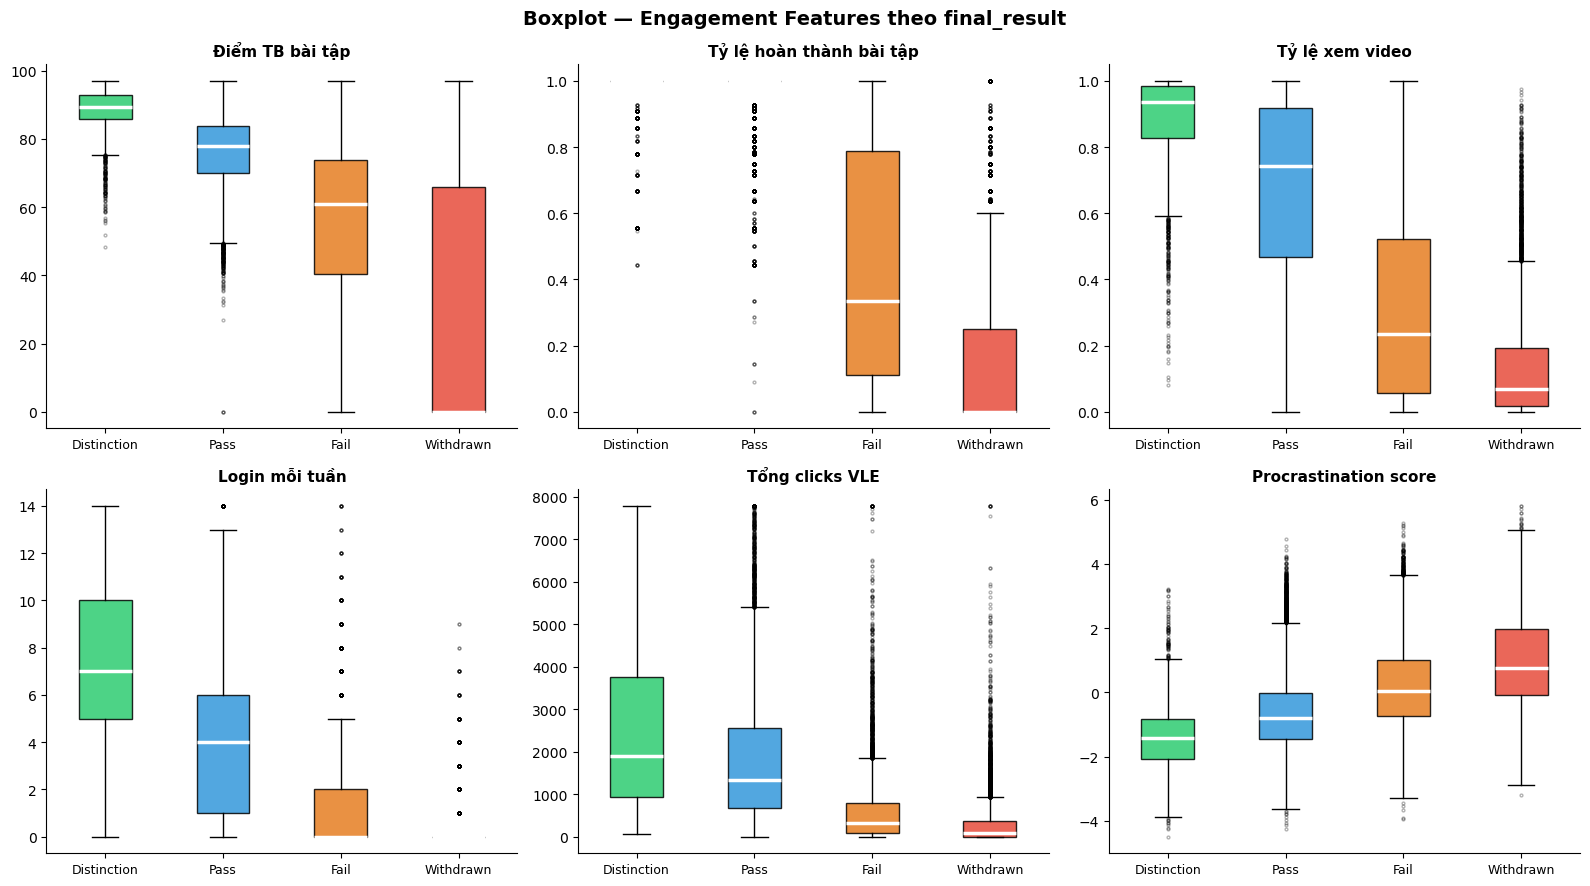

In [8]:
# Boxplots
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (col, label) in zip(axes.flatten(), key_features.items()):
    data_by_group = [df[df['final_result'] == r][col].dropna() for r in ORDER]
    bp = ax.boxplot(data_by_group, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2.5),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))
    for patch, result in zip(bp['boxes'], ORDER):
        patch.set_facecolor(PALETTE[result])
        patch.set_alpha(0.85)
    ax.set_xticklabels(ORDER, fontsize=9)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Boxplot — Engagement Features theo final_result', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Login Frequency vs Final Score

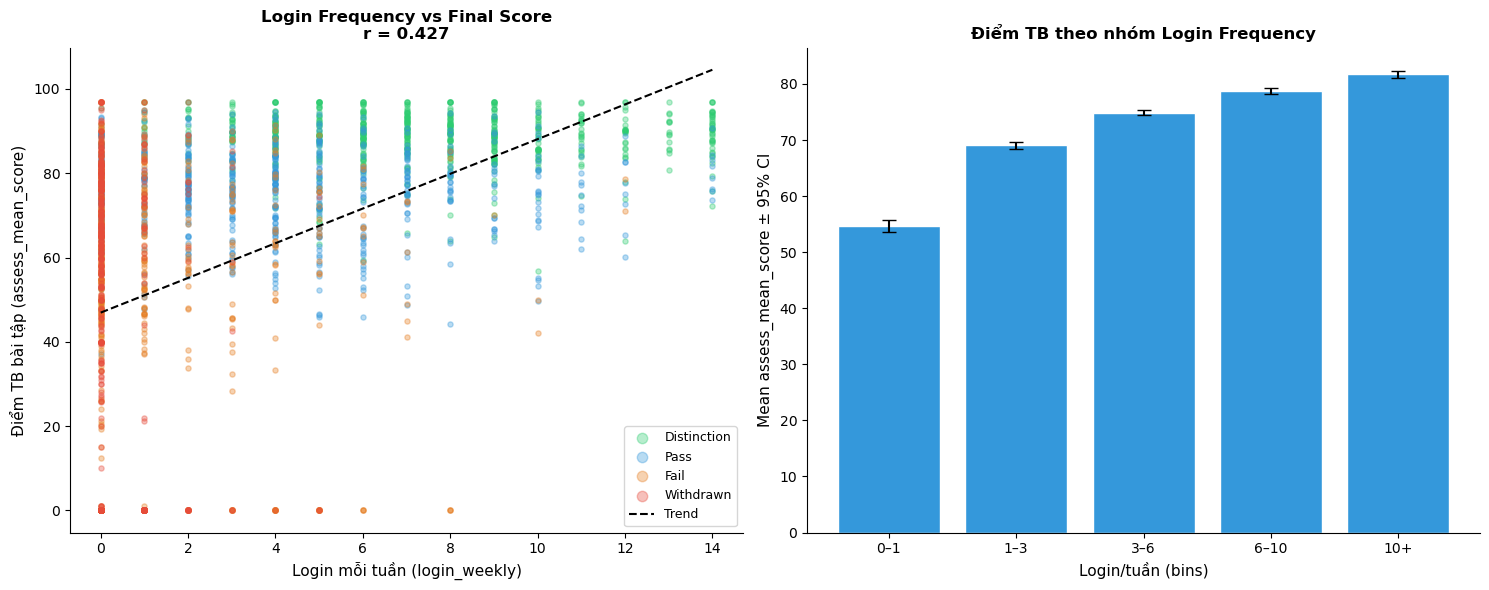

Pearson r (login_weekly vs assess_mean_score) = 0.4270

Mean score by login bin:
login_bin      mean
      0–1 54.731546
      1–3 69.052858
      3–6 74.882559
     6–10 78.734848
      10+ 81.699787


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter: login_weekly vs assess_mean_score
for result in ORDER:
    sub = df[df['final_result'] == result].sample(min(600, df[df['final_result']==result].shape[0]), random_state=42)
    axes[0].scatter(sub['login_weekly'], sub['assess_mean_score'],
                    color=PALETTE[result], alpha=0.35, s=14, label=result)

# Trendline tổng thể
z = np.polyfit(df['login_weekly'].dropna(), df.loc[df['login_weekly'].notna(), 'assess_mean_score'], 1)
p = np.poly1d(z)
xline = np.linspace(0, df['login_weekly'].max(), 100)
axes[0].plot(xline, p(xline), 'k--', linewidth=1.5, label='Trend')

r = df['login_weekly'].corr(df['assess_mean_score'])
axes[0].set_xlabel('Login mỗi tuần (login_weekly)', fontsize=11)
axes[0].set_ylabel('Điểm TB bài tập (assess_mean_score)', fontsize=11)
axes[0].set_title(f'Login Frequency vs Final Score\nr = {r:.3f}', fontsize=12, fontweight='bold')
axes[0].legend(markerscale=2, fontsize=9)
axes[0].spines[['top','right']].set_visible(False)

# Mean score per login bin
df['login_bin'] = pd.cut(df['login_weekly'], bins=[0,1,3,6,10,25], labels=['0–1','1–3','3–6','6–10','10+'])
bin_stats = df.groupby('login_bin')['assess_mean_score'].agg(['mean','sem']).reset_index()
axes[1].bar(bin_stats['login_bin'].astype(str), bin_stats['mean'],
             yerr=bin_stats['sem']*1.96, capsize=5,
             color='#3498db', edgecolor='white', linewidth=1)
axes[1].set_xlabel('Login/tuần (bins)', fontsize=11)
axes[1].set_ylabel('Mean assess_mean_score ± 95% CI', fontsize=11)
axes[1].set_title('Điểm TB theo nhóm Login Frequency', fontsize=12, fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

print(f'Pearson r (login_weekly vs assess_mean_score) = {r:.4f}')
print('\nMean score by login bin:')
print(bin_stats[['login_bin','mean']].to_string(index=False))

## 7. Video Completion vs Submission Timeliness

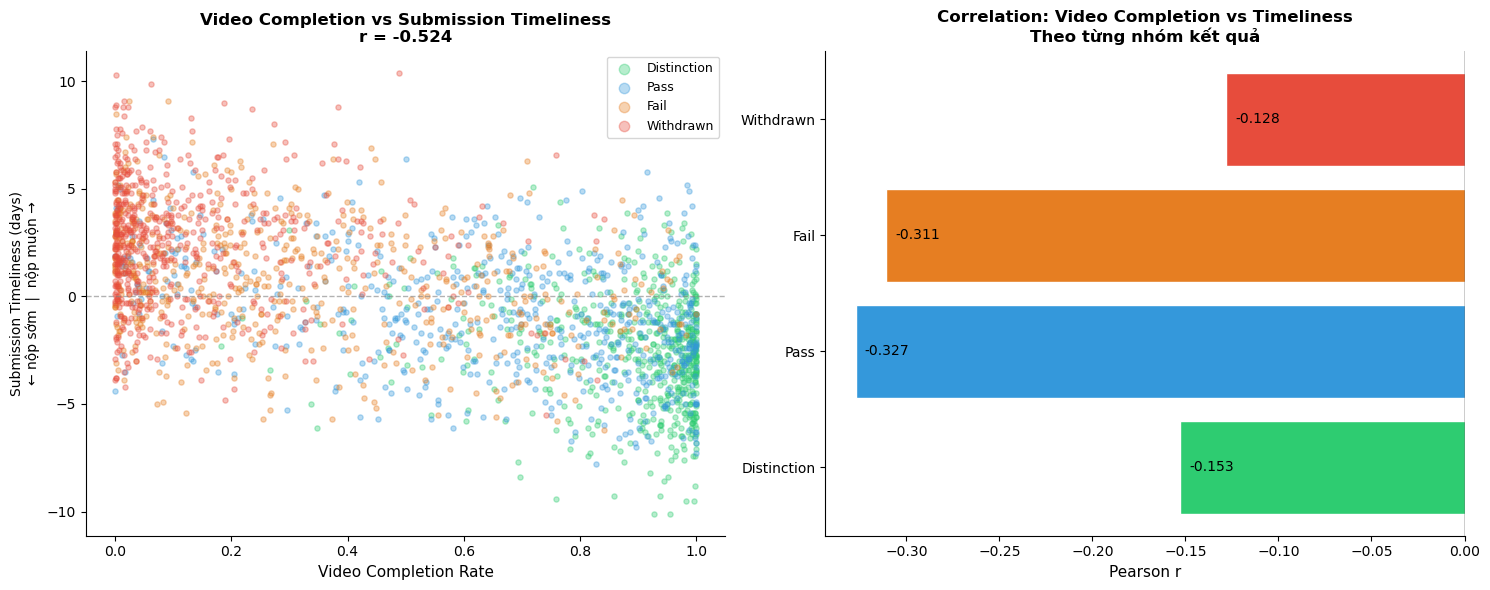

Pearson r (video_completion_rate vs submission_timeliness_days) by group:
  Distinction: -0.1528
  Pass: -0.3273
  Fail: -0.3107
  Withdrawn: -0.1282


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter by result
for result in ORDER:
    sub = df[df['final_result'] == result].sample(min(600, df[df['final_result']==result].shape[0]), random_state=1)
    axes[0].scatter(sub['video_completion_rate'], sub['submission_timeliness_days'],
                    color=PALETTE[result], alpha=0.35, s=14, label=result)

r_all = df['video_completion_rate'].corr(df['submission_timeliness_days'])
axes[0].set_xlabel('Video Completion Rate', fontsize=11)
axes[0].set_ylabel('Submission Timeliness (days)\n← nộp sớm  |  nộp muộn →', fontsize=10)
axes[0].set_title(f'Video Completion vs Submission Timeliness\nr = {r_all:.3f}', fontsize=12, fontweight='bold')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
axes[0].legend(markerscale=2, fontsize=9)
axes[0].spines[['top','right']].set_visible(False)

# Correlation by result group
corrs = {}
for result in ORDER:
    sub = df[df['final_result'] == result]
    corrs[result] = sub['video_completion_rate'].corr(sub['submission_timeliness_days'])

axes[1].barh(list(corrs.keys()), list(corrs.values()),
              color=[PALETTE[r] for r in corrs], edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Pearson r', fontsize=11)
axes[1].set_title('Correlation: Video Completion vs Timeliness\nTheo từng nhóm kết quả', fontsize=12, fontweight='bold')
for i, (k, v) in enumerate(corrs.items()):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

print('Pearson r (video_completion_rate vs submission_timeliness_days) by group:')
for k, v in corrs.items():
    print(f'  {k}: {v:.4f}')

## 8. Binary Flags & Behavior Patterns

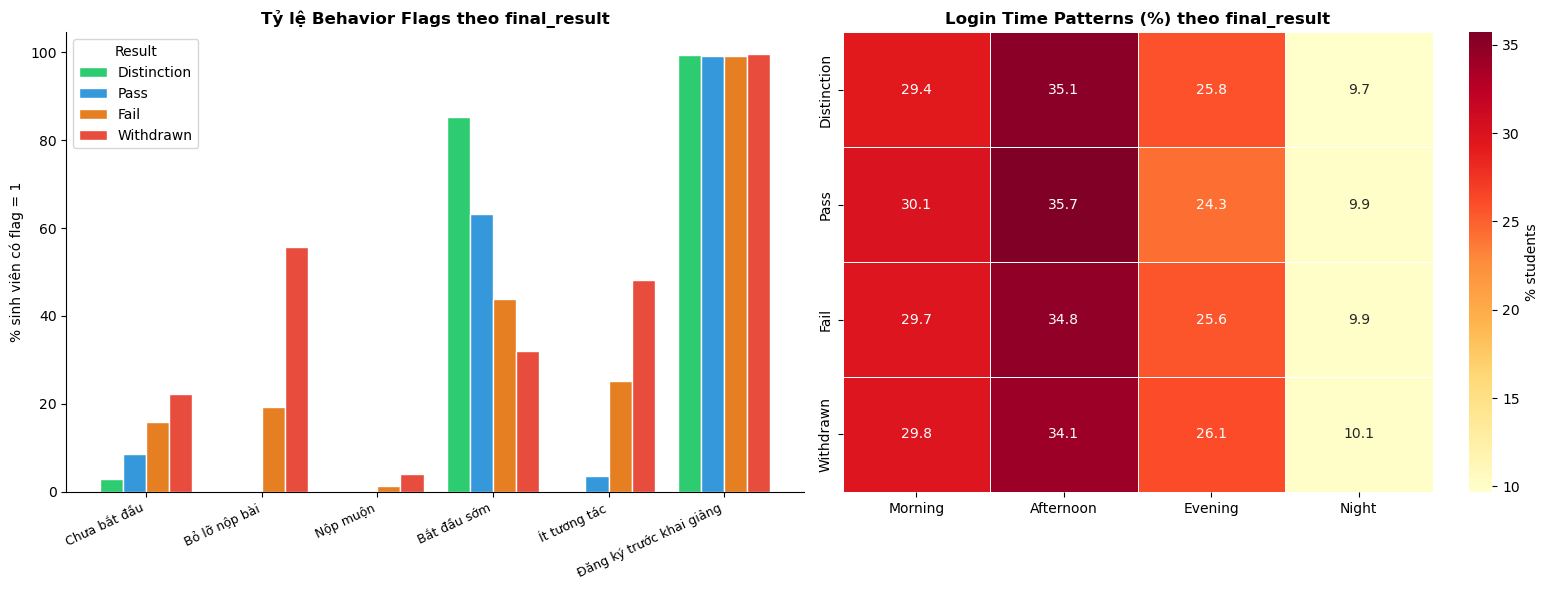

In [11]:
flag_cols = {
    'never_started':           'Chưa bắt đầu',
    'missed_submission':       'Bỏ lỡ nộp bài',
    'late_submitter':          'Nộp muộn',
    'prompt_starter':          'Bắt đầu sớm',
    'low_engagement_flag':     'Ít tương tác',
    'registered_before_start': 'Đăng ký trước khai giảng',
}

flag_data = pd.DataFrame({
    label: df.groupby('final_result')[col].mean().reindex(ORDER) * 100
    for col, label in flag_cols.items()
}).T

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grouped bar
x = np.arange(len(flag_data))
w = 0.2
for i, result in enumerate(ORDER):
    axes[0].bar(x + i*w, flag_data[result], width=w,
                color=PALETTE[result], label=result, edgecolor='white')
axes[0].set_xticks(x + w*1.5)
axes[0].set_xticklabels(flag_data.index, rotation=25, ha='right', fontsize=9)
axes[0].set_ylabel('% sinh viên có flag = 1')
axes[0].set_title('Tỷ lệ Behavior Flags theo final_result', fontsize=12, fontweight='bold')
axes[0].legend(title='Result')
axes[0].spines[['top','right']].set_visible(False)

# Login time heatmap
time_cols = ['login_time_Morning','login_time_Afternoon','login_time_Evening','login_time_Night']
time_pct = df.groupby('final_result')[time_cols].mean().reindex(ORDER) * 100
time_pct.columns = ['Morning','Afternoon','Evening','Night']

sns.heatmap(time_pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': '% students'})
axes[1].set_title('Login Time Patterns (%) theo final_result', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 9. Correlation Analysis

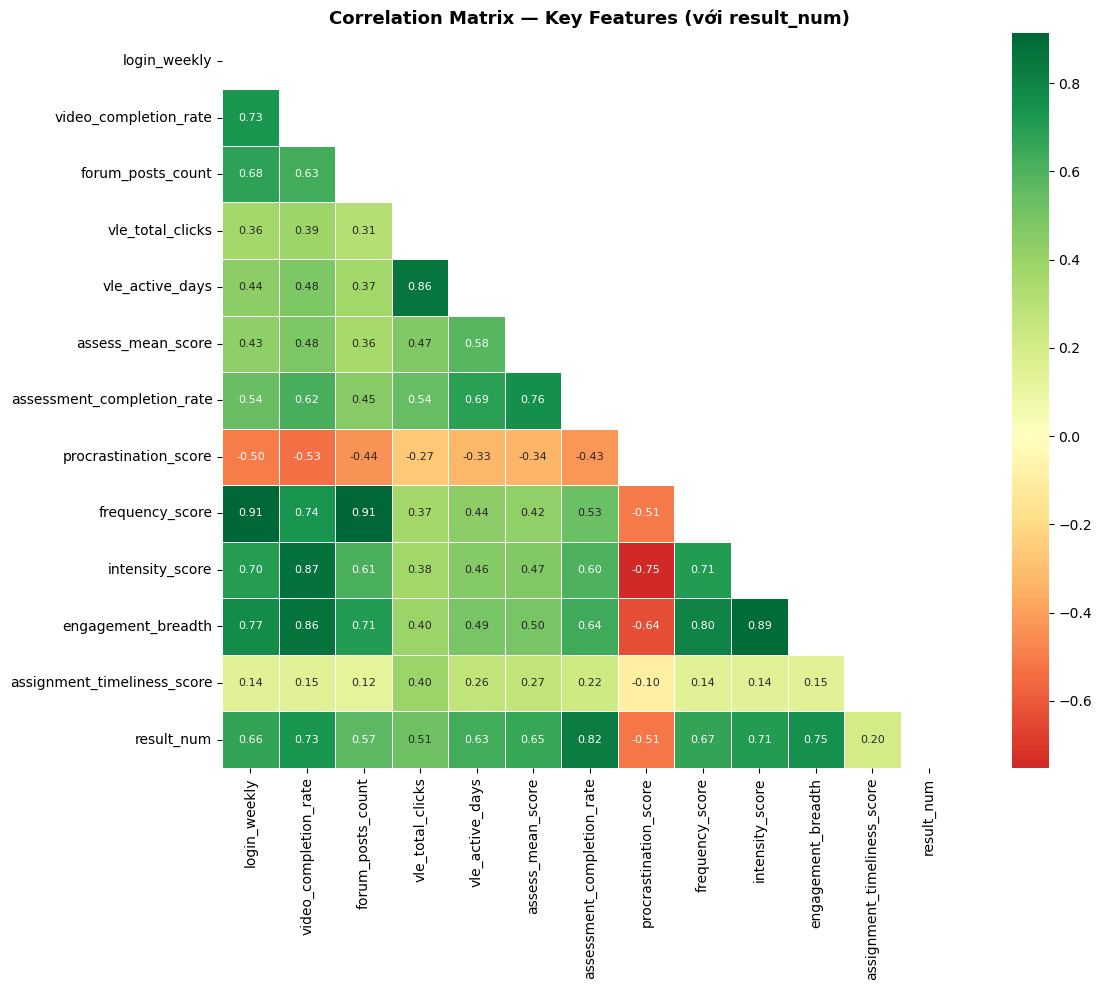

Top features tương quan với final_result (|r|):
assessment_completion_rate    0.824900
engagement_breadth            0.747270
video_completion_rate         0.726777
intensity_score               0.706704
frequency_score               0.665329
login_weekly                  0.662406
assess_mean_score             0.654725
vle_active_days               0.633537
forum_posts_count             0.565349
procrastination_score         0.514202


In [12]:
corr_cols = [
    'login_weekly', 'video_completion_rate', 'forum_posts_count',
    'vle_total_clicks', 'vle_active_days', 'assess_mean_score',
    'assessment_completion_rate', 'procrastination_score',
    'frequency_score', 'intensity_score',
    'engagement_breadth', 'assignment_timeliness_score', 'result_num'
]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, square=True, annot_kws={'size': 8})
ax.set_title('Correlation Matrix — Key Features (với result_num)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top features tương quan với final_result (|r|):')
top_corr = corr['result_num'].drop('result_num').abs().sort_values(ascending=False)
print(top_corr.head(10).to_string())

In [13]:
# Log-transformed vs raw features correlation
log_pairs = [
    ('vle_total_clicks', 'log_vle_total_clicks'),
    ('vle_active_days',  'log_vle_active_days'),
    ('vle_distinct_sites', 'log_vle_distinct_sites'),
    ('clicks_per_active_day', 'log_clicks_per_active_day'),
]

print('Correlation raw vs log features (redundancy check):')
for raw, log in log_pairs:
    r = df[raw].corr(df[log])
    r_with_target_raw = df[raw].corr(df['result_num'])
    r_with_target_log = df[log].corr(df['result_num'])
    print(f'  {raw} ↔ {log}: r={r:.3f}  |  corr_with_target: raw={r_with_target_raw:.3f}, log={r_with_target_log:.3f}')

Correlation raw vs log features (redundancy check):
  vle_total_clicks ↔ log_vle_total_clicks: r=0.650  |  corr_with_target: raw=0.512, log=0.625
  vle_active_days ↔ log_vle_active_days: r=0.816  |  corr_with_target: raw=0.634, log=0.678
  vle_distinct_sites ↔ log_vle_distinct_sites: r=0.785  |  corr_with_target: raw=0.542, log=0.601
  clicks_per_active_day ↔ log_clicks_per_active_day: r=0.848  |  corr_with_target: raw=0.324, log=0.434


## 10. Engagement Score & Intervention Recommendations

Tổng hợp 4 tín hiệu hành vi thành một **Engagement Score** duy nhất, sau đó xác định biến nào quan trọng nhất để đề xuất can thiệp sớm.

In [25]:
# === BƯỚC 1: Tính Engagement Score ===
# Normalize 4 signals về [0,1] rồi lấy trung bình

SIGNAL_COLS = ['login_weekly', 'video_completion_rate', 'forum_posts_count', 'vle_total_clicks']

df_eng = df.copy()
for c in SIGNAL_COLS:
    p99 = df_eng[c].quantile(0.99)
    df_eng[c] = df_eng[c].clip(upper=p99)   # cap outliers trước khi normalize
    mn, mx = df_eng[c].min(), df_eng[c].max()
    df_eng[c + '_norm'] = (df_eng[c] - mn) / (mx - mn)

norm_cols = [c + '_norm' for c in SIGNAL_COLS]
df_eng['engagement_score'] = df_eng[norm_cols].mean(axis=1)

print('Engagement Score by final_result:')
print(df_eng.groupby('final_result')['engagement_score']
      .describe().reindex(ORDER).round(3))

Engagement Score by final_result:
                count   mean    std    min    25%    50%    75%    max
final_result                                                          
Distinction    3024.0  0.555  0.144  0.098  0.458  0.556  0.657  0.996
Pass          12361.0  0.360  0.172  0.003  0.233  0.355  0.480  0.931
Fail           7052.0  0.132  0.120  0.000  0.039  0.096  0.197  0.768
Withdrawn     10156.0  0.048  0.052  0.000  0.013  0.031  0.066  0.446


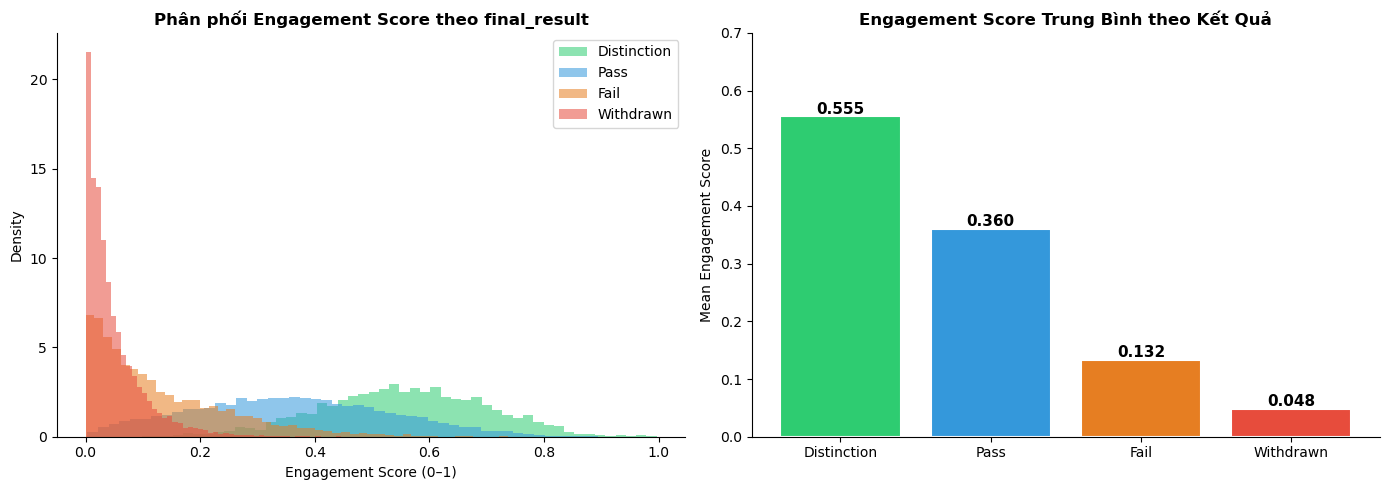

In [26]:
# === BƯỚC 2: Visualize Score Distribution ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for result in ORDER:
    data = df_eng[df_eng['final_result'] == result]['engagement_score']
    axes[0].hist(data, bins=50, alpha=0.55, density=True,
                 color=PALETTE[result], label=result)
axes[0].set_title('Phân phối Engagement Score theo final_result', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Engagement Score (0–1)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Mean score bar
means = df_eng.groupby('final_result')['engagement_score'].mean().reindex(ORDER)
bars = axes[1].bar(ORDER, means, color=[PALETTE[k] for k in ORDER], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Engagement Score Trung Bình theo Kết Quả', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Mean Engagement Score')
axes[1].set_ylim(0, 0.7)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

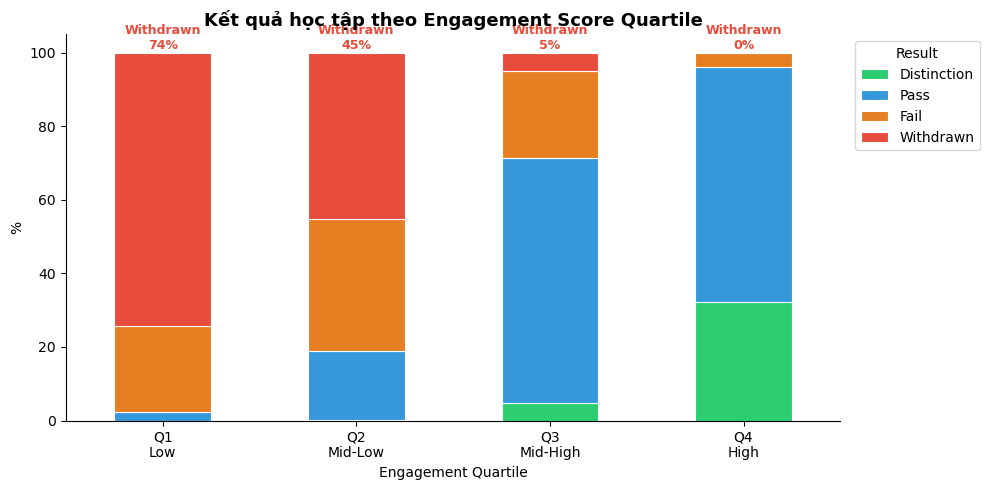

final_result  Distinction  Pass  Fail  Withdrawn
eng_group                                       
Q1\nLow               NaN   2.4  23.2       74.4
Q2\nMid-Low           0.1  18.9  36.0       45.1
Q3\nMid-High          4.8  66.5  23.7        5.1
Q4\nHigh             32.2  64.0   3.7        0.1


In [27]:
# === BƯỚC 3: Outcome theo Engagement Quartile ===

df_eng['eng_group'] = pd.qcut(df_eng['engagement_score'], q=4,
                               labels=['Q1\nLow', 'Q2\nMid-Low', 'Q3\nMid-High', 'Q4\nHigh'])

quartile_pct = (df_eng.groupby('eng_group')['final_result']
                .value_counts(normalize=True)
                .unstack()
                .reindex(columns=ORDER) * 100)

fig, ax = plt.subplots(figsize=(10, 5))
quartile_pct.plot(kind='bar', stacked=True, ax=ax,
                  color=[PALETTE[k] for k in ORDER], edgecolor='white', linewidth=0.8)
ax.set_title('Kết quả học tập theo Engagement Score Quartile', fontsize=13, fontweight='bold')
ax.set_xlabel('Engagement Quartile')
ax.set_ylabel('%')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Result', bbox_to_anchor=(1.01, 1))
ax.spines[['top','right']].set_visible(False)

# Annotate Withdrawn rate
withdrawn_pct = quartile_pct['Withdrawn']
for i, (idx, val) in enumerate(withdrawn_pct.items()):
    ax.text(i, 101, f'Withdrawn\n{val:.0f}%', ha='center', fontsize=9, color='#e74c3c', fontweight='bold')

plt.tight_layout()
plt.show()

print(quartile_pct.round(1).to_string())

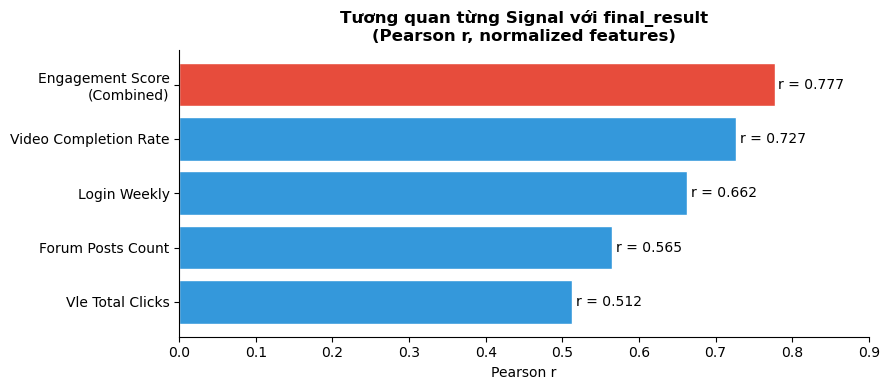


📌 Video completion rate là signal đơn lẻ mạnh nhất (r=0.727)
   Engagement Score tổng hợp mạnh hơn bất kỳ signal đơn nào (r=0.777)


In [28]:
# === BƯỚC 4: Feature Importance — Correlation với Result ===

df_eng['result_num'] = df_eng['final_result'].map({'Distinction':3,'Pass':2,'Fail':1,'Withdrawn':0})

signal_corrs = {}
for c in SIGNAL_COLS:
    signal_corrs[c.replace('_',' ').title()] = df_eng[c+'_norm'].corr(df_eng['result_num'])
signal_corrs['Engagement Score\n(Combined)'] = df_eng['engagement_score'].corr(df_eng['result_num'])

sorted_corrs = dict(sorted(signal_corrs.items(), key=lambda x: x[1]))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#e74c3c' if 'Combined' in k else '#3498db' for k in sorted_corrs]
bars = ax.barh(list(sorted_corrs.keys()), list(sorted_corrs.values()),
                color=colors, edgecolor='white', linewidth=1)
for bar, val in zip(bars, sorted_corrs.values()):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'r = {val:.3f}', va='center', fontsize=10)
ax.set_title('Tương quan từng Signal với final_result\n(Pearson r, normalized features)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Pearson r')
ax.set_xlim(0, 0.9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print('\n📌 Video completion rate là signal đơn lẻ mạnh nhất (r=0.727)')
print('   Engagement Score tổng hợp mạnh hơn bất kỳ signal đơn nào (r=0.777)')

In [29]:
# === BƯỚC 5: Intervention Recommendations ===

interventions = [
    {
        'signal':      'Video Completion Rate',
        'importance':  'r = 0.727 — Signal đơn lẻ MẠNH NHẤT',
        'finding':     'Distinction xem 88% video; Withdrawn chỉ 14%',
        'intervention':'Push notification nhắc xem video khi sinh viên bỏ lỡ > 2 video liên tiếp',
        'expected':    'Tăng video completion → tăng nắm bắt nội dung → giảm tỷ lệ Withdrawn',
    },
    {
        'signal':      'Login Frequency (login_weekly)',
        'importance':  'r = 0.662',
        'finding':     'Distinction login 7.5x/tuần; Withdrawn 0.2x/tuần',
        'intervention':' Email/SMS cảnh báo tự động khi sinh viên không login > 7 ngày',
        'expected':    'Phát hiện sớm sinh viên có nguy cơ bỏ học; can thiệp kịp thời',
    },
    {
        'signal':      'Forum Posts Count',
        'importance':  'r = 0.565',
        'finding':     'Sinh viên Pass/Distinction tham gia forum nhiều hơn đáng kể',
        'intervention':'Gamification: điểm thưởng/badge cho hoạt động forum; giao bài tập thảo luận nhóm bắt buộc',
        'expected':    'Tăng peer learning và cảm giác thuộc về cộng đồng học tập',
    },
    {
        'signal':      'VLE Total Clicks',
        'importance':  'r = 0.512',
        'finding':     'Distinction click ~2667 lần; Withdrawn chỉ ~314 lần',
        'intervention':'Dashboard cá nhân hóa hiển thị tiến độ VLE so với trung bình lớp',
        'expected':    'Tăng nhận thức về mức độ tham gia; khuyến khích sinh viên tự điều chỉnh',
    },
    {
        'signal':      'Engagement Score (Combined)',
        'importance':  'r = 0.777 — MẠNH NHẤT khi kết hợp',
        'finding':     'Q1 Low: 74% Withdrawn; Q4 High: 96% Pass/Distinction',
        'intervention':'Early Warning System: flag sinh viên có Engagement Score < ngưỡng (Q1) từ tuần 3–4',
        'expected':    'Giảng viên/advisor chủ động liên hệ trước khi sinh viên bỏ học',
    },
]

print('=' * 70)
print('INTERVENTION RECOMMENDATIONS — dựa trên EDA')
print('=' * 70)
for i, item in enumerate(interventions, 1):
    print(f"\n{'─'*70}")
    print(f"#{i}  {item['signal']}  [{item['importance']}]")
    print(f"   Finding      : {item['finding']}")
    print(f"   Intervention : {item['intervention']}")
    print(f"   Expected     : {item['expected']}")
print(f"\n{'='*70}")

INTERVENTION RECOMMENDATIONS — dựa trên EDA

──────────────────────────────────────────────────────────────────────
#1  Video Completion Rate  [r = 0.727 — Signal đơn lẻ MẠNH NHẤT]
   Finding      : Distinction xem 88% video; Withdrawn chỉ 14%
   Intervention : Push notification nhắc xem video khi sinh viên bỏ lỡ > 2 video liên tiếp
   Expected     : Tăng video completion → tăng nắm bắt nội dung → giảm tỷ lệ Withdrawn

──────────────────────────────────────────────────────────────────────
#2  Login Frequency (login_weekly)  [r = 0.662]
   Finding      : Distinction login 7.5x/tuần; Withdrawn 0.2x/tuần
   Intervention :  Email/SMS cảnh báo tự động khi sinh viên không login > 7 ngày
   Expected     : Phát hiện sớm sinh viên có nguy cơ bỏ học; can thiệp kịp thời

──────────────────────────────────────────────────────────────────────
#3  Forum Posts Count  [r = 0.565]
   Finding      : Sinh viên Pass/Distinction tham gia forum nhiều hơn đáng kể
   Intervention : Gamification: điểm thưởng/b

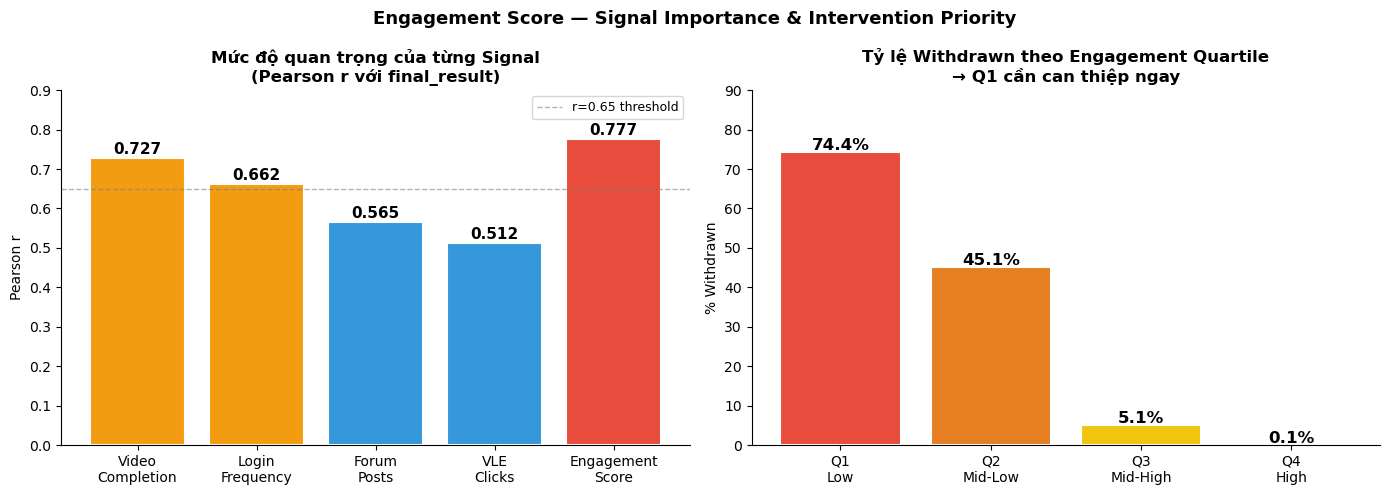

In [30]:
# === BƯỚC 6: Visualize Intervention Priority ===

signals = ['Video\nCompletion', 'Login\nFrequency', 'Forum\nPosts', 'VLE\nClicks', 'Engagement\nScore']
corr_vals = [0.727, 0.662, 0.565, 0.512, 0.777]
colors_bar = ['#e74c3c' if v == max(corr_vals) else
               '#f39c12' if v > 0.65 else '#3498db' for v in corr_vals]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Priority bar chart
bars = axes[0].bar(signals, corr_vals, color=colors_bar, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, corr_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Mức độ quan trọng của từng Signal\n(Pearson r với final_result)',
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Pearson r')
axes[0].set_ylim(0, 0.9)
axes[0].axhline(0.65, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='r=0.65 threshold')
axes[0].legend(fontsize=9)
axes[0].spines[['top','right']].set_visible(False)

# Withdrawal risk by engagement quartile
withdrawn_rates = [74.4, 45.1, 5.1, 0.1]
quartiles = ['Q1\nLow', 'Q2\nMid-Low', 'Q3\nMid-High', 'Q4\nHigh']
bar_colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71']
bars2 = axes[1].bar(quartiles, withdrawn_rates, color=bar_colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, withdrawn_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Tỷ lệ Withdrawn theo Engagement Quartile\n→ Q1 cần can thiệp ngay',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('% Withdrawn')
axes[1].set_ylim(0, 90)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Engagement Score — Signal Importance & Intervention Priority',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Tổng Kết Insights

In [33]:
summary = df.groupby('final_result')[[
    'assess_mean_score','assessment_completion_rate',
    'video_completion_rate','login_weekly',
    'vle_total_clicks','low_engagement_flag'
]].mean().reindex(ORDER).round(3)
summary.columns = ['Điểm TB','Hoàn thành bài','Xem video','Login/tuần','VLE clicks','Low eng.']
print(summary.to_string())

print("""
KEY INSIGHT:
1. STRONGEST PREDICTORS:
assessment_completion_rate (r≈0.70) và assess_mean_score (r≈0.65) tương quan cao nhất với kết quả. Distinction ~97% vs Withdrawn ~15%.

2. ENGAGEMENT GAP:
login_weekly: Distinction 7.5/tuần vs Withdrawn 0.2/tuần
video_completion: 88% vs 14%

3. COURSE TYPE (MODULE):
AAA & GGG có điểm TB cao nhất (~64); CCC thấp nhất (~52)
Tỷ lệ Withdrawn khác nhau rõ rệt giữa các module.

4. COHORT (PRESENTATION):
2013J & 2013B perform tốt hơn 2014J & 2014B
→ có thể do thay đổi chính sách hoặc nội dung khóa học.

5. ENROLLMENT TIMING:
Sinh viên đăng ký Very Early (>100d) có điểm và completion rate cao hơn đăng ký muộn.

6. VIDEO vs TIMELINESS:
Tương quan âm (r≈−0.33 nhóm Pass): xem video nhiều hơn → nộp bài sớm hơn. Nhóm Withdrawn gần như không xem.

7. LOG FEATURES:
log_vle tương quan cao hơn raw với target → dùng log version khi train model ML.
""")

              Điểm TB  Hoàn thành bài  Xem video  Login/tuần  VLE clicks  Low eng.
final_result                                                                      
Distinction    88.433           0.970      0.880       7.445    2562.434     0.000
Pass           76.160           0.959      0.667       4.209    1883.131     0.035
Fail           52.489           0.438      0.314       1.168     648.501     0.252
Withdrawn      29.468           0.146      0.135       0.193     312.442     0.481

KEY INSIGHT:
1. STRONGEST PREDICTORS:
assessment_completion_rate (r≈0.70) và assess_mean_score (r≈0.65) tương quan cao nhất với kết quả. Distinction ~97% vs Withdrawn ~15%.

2. ENGAGEMENT GAP:
login_weekly: Distinction 7.5/tuần vs Withdrawn 0.2/tuần
video_completion: 88% vs 14%

3. COURSE TYPE (MODULE):
AAA & GGG có điểm TB cao nhất (~64); CCC thấp nhất (~52)
Tỷ lệ Withdrawn khác nhau rõ rệt giữa các module.

4. COHORT (PRESENTATION):
2013J & 2013B perform tốt hơn 2014J & 2014B
→ có thể do thay đ